In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


In [1]:


# Load and prepare data
d = pd.read_csv('../data/clean_house_data.csv')
d = d.drop('Id', axis=1)
d.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


Correlation between Area and Price:  0.008333


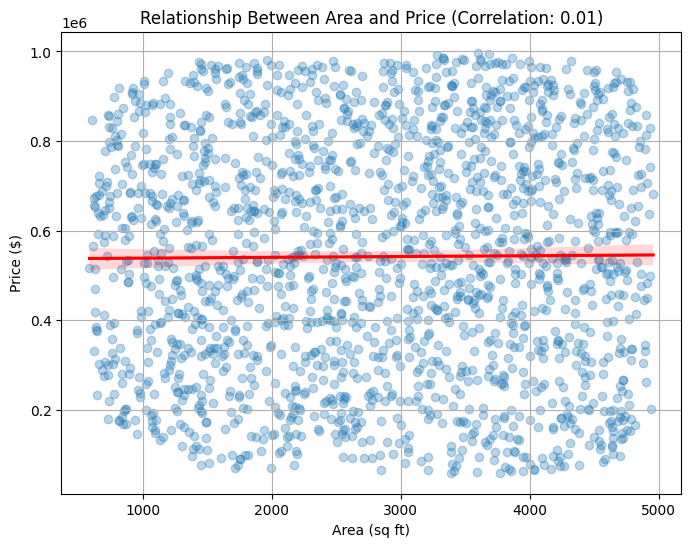

In [ ]:
# Area analysis
e = d.copy()

df = e[["Area","Price"]].dropna()
correlation = df.corr().loc['Area','Price']
print(f"Correlation between Area and Price: {correlation: 2f}")

# Scatter plot with trend line
plt.figure(figsize=(8,6))
sns.regplot(x=df["Area"], y=df["Price"],scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title(f"Relationship Between Area and Price (Correlation: {correlation:.2f})")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price ($)")
plt.grid(True)
plt.show()

Correlation between Floors and Price:  0.060998


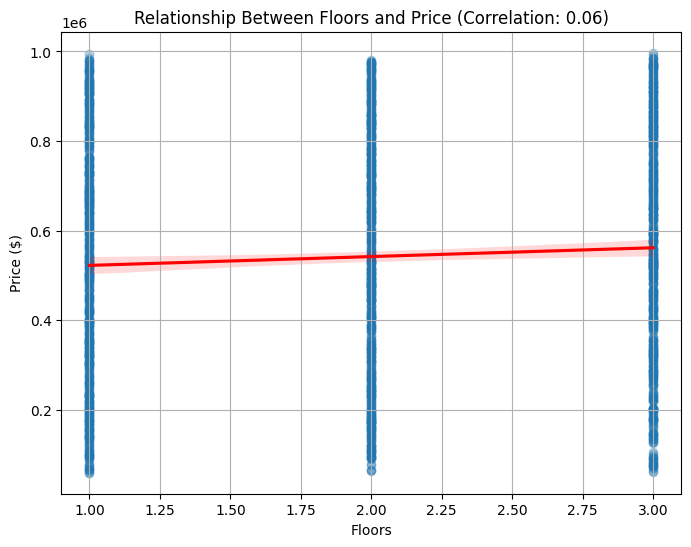

In [10]:
# Bedroom
e = d.copy()

df = e[["Floors","Price"]].dropna()
correlation = df.corr().loc['Floors','Price']
print(f"Correlation between Floors and Price: {correlation: 2f}")

# Scatter plot with trend line
plt.figure(figsize=(8,6))
sns.regplot(x=df["Floors"], y=df["Price"],scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title(f"Relationship Between Floors and Price (Correlation: {correlation:.2f})")
plt.xlabel("Floors")
plt.ylabel("Price ($)")
plt.grid(True)
plt.show()

In [12]:
e = d.copy()

df = e[["Area","Bathrooms","Bedrooms","Floors","Price"]].dropna()
df["Area_Bathrooms"] = df["Area"] * df["Bathrooms"]
df["Area_Bedrooms"] = df["Area"] * df["Bedrooms"]
df["Area_Floors"] = df["Area"] * df["Floors"]
df["Bathrooms_Floors"] = df["Bathrooms"] * df["Floors"]
df["Bedrooms_Floors"] = df["Bedrooms"] * df["Floors"]

correlations = df.corr()["Price"].sort_values(ascending=False)
print("Correlation with Price")
print(correlations)

Correlation with Price
Price               1.000000
Floors              0.060998
Area_Floors         0.053924
Bedrooms_Floors     0.049871
Bathrooms_Floors    0.026510
Area_Bedrooms       0.018632
Area                0.008333
Bedrooms            0.007393
Area_Bathrooms      0.000723
Bathrooms          -0.005587
Name: Price, dtype: float64


In [15]:
X = df[["Area","Bathrooms","Bedrooms","Floors","Area_Bathrooms","Area_Floors","Bathrooms_Floors","Bedrooms_Floors"]]
y = df["Price"]
model = LinearRegression()
model.fit(X,y)
r_squared = model.score(X,y)
coefficients = dict(zip(X.columns, model.coef_))
intercept = model.intercept_

# Display Regression Results
print("\nMultiple Linear Regression Results:")
print(f"R-Squared: {r_squared:.2f}")
print("Coefficients:")
for feature, coef in coefficients.items():
    print(f"{feature}: {coef: .2f}")
print(f"Intercept: {intercept:.2f}")


Multiple Linear Regression Results:
R-Squared: 0.01
Coefficients:
Area: -12.81
Bathrooms:  19442.29
Bedrooms: -8003.21
Floors:  9332.18
Area_Bathrooms: -0.53
Area_Floors:  7.84
Bathrooms_Floors: -9996.32
Bedrooms_Floors:  4668.21
Intercept: 516415.97


Correlations with Price:
Price                1.000000
Floors               0.060998
Area_Floors          0.053924
Bedrooms_Floors      0.049871
Condition_Fair       0.037886
Location_Suburban    0.036300
Age_Floors           0.030865
Bathrooms_Floors     0.026510
Area_Bedrooms        0.018632
YearBuilt            0.016425
Area                 0.008333
Bedrooms             0.007393
Poor_New             0.002121
Area_Bathrooms       0.000723
Age_Area            -0.001206
Bathrooms           -0.005587
Garage_Yes          -0.006486
Location_Rural      -0.007001
Age_Bathrooms       -0.010631
Age_Bedrooms        -0.011265
Fair_Good_Old       -0.015198
Age                 -0.016425
Condition_Good      -0.019704
Condition_Poor      -0.035495
Location_Urban      -0.036312
Name: Price, dtype: float64


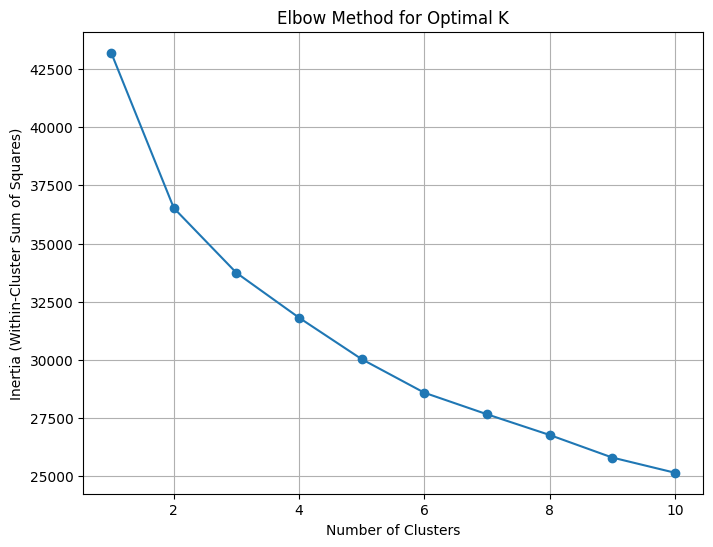

' \nX_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)\nmodel = RandomForestRegressor(n_estimators = 100, max_depth=9, min_samples_split=20, min_samples_leaf=10,max_features="sqrt", random_state=42)\nmodel.fit(X_train, y_train)\n\ny_pred_train = model.predict(X_train)\ny_pred_test = model.predict(X_test)\n\nr_squared_train = r2_score(y_train, y_pred_train)\nr_squared_test = r2_score(y_test, y_pred_test)\n\n# Display model results\nprint("\nRandom Forest Regression Results")\nprint(f"Train R-Squared: {r_squared_train:.2f}")\nprint(f"Test R-Squared: {r_squared_test: .2f}")\n'

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

e = d.copy()

df =e[["Area","Bathrooms","Bedrooms","Floors","Price","YearBuilt", "Location","Condition","Garage"]].dropna()

# Encode categorical location using one-hot encoding
df =pd.get_dummies(df, columns=["Location", "Condition","Garage"], drop_first=True)


# Creating Age
df["Age"] = 2025-df["YearBuilt"]

# Create interaction terms
df["Area_Bathrooms"] = df["Area"] * df["Bathrooms"]
df["Area_Bedrooms"] = df["Area"] * df["Bedrooms"]
df["Area_Floors"] = df["Area"]* df["Floors"]
df["Bathrooms_Floors"] = df["Bathrooms"] * df["Floors"]
df["Bedrooms_Floors"] = df["Bedrooms"] * df["Floors"]
df["Age_Floors"] = df["Age"] * df["Floors"]
df["Age_Area"] = df["Age"] * df["Area"]
df["Age_Bathrooms"] = df["Age"] * df["Bathrooms"]
df["Age_Bedrooms"] = df["Age"] * df["Bedrooms"]

# Capture condition deterioration trends
df["Poor_New"] = ((df["Age"] < 10) & (df["Condition_Poor"] == 1)).astype(int)
df["Fair_Good_Old"] = ((df["Age"]>50) & ((df["Condition_Fair"]==1) | (df["Condition_Good"] == 1))).astype(int)

# Compute correlation with Price
correlations = df.corr()["Price"].sort_values(ascending=False)
print("Correlations with Price:")
print(correlations)

# Standardize features for clustering
X=df.drop(columns=["Price"])
y = df["Price"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using Elbow Method
inertia = []
k_values = range(1,11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow method
plt.figure(figsize=(8,6))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

''' 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators = 100, max_depth=9, min_samples_split=20, min_samples_leaf=10,max_features="sqrt", random_state=42)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

r_squared_train = r2_score(y_train, y_pred_train)
r_squared_test = r2_score(y_test, y_pred_test)

# Display model results
print("\nRandom Forest Regression Results")
print(f"Train R-Squared: {r_squared_train:.2f}")
print(f"Test R-Squared: {r_squared_test: .2f}")
'''

In [42]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
df.head()

,Area,Bathrooms,Bedrooms,Floors,Price,YearBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,...,Area_Floors,Bathrooms_Floors,Bedrooms_Floors,Age_Floors,Age_Area,Age_Bathrooms,Age_Bedrooms,Poor_New,Fair_Good_Old,Cluster
0,1360,4,5,3,149919,1970,False,False,False,False,...,4080,12,15,165,74800,220,275,0,0,3
1,4272,4,5,3,424998,1958,False,False,False,False,...,12816,12,15,201,286224,268,335,0,0,3
2,3592,2,2,3,266746,1938,False,False,False,False,...,10776,6,6,261,312504,174,174,0,1,3
3,966,2,4,2,244020,1902,False,True,False,True,...,1932,4,8,246,118818,246,492,0,1,1
4,4926,4,1,2,636056,1975,False,False,False,True,...,9852,8,2,100,246300,200,50,0,0,2


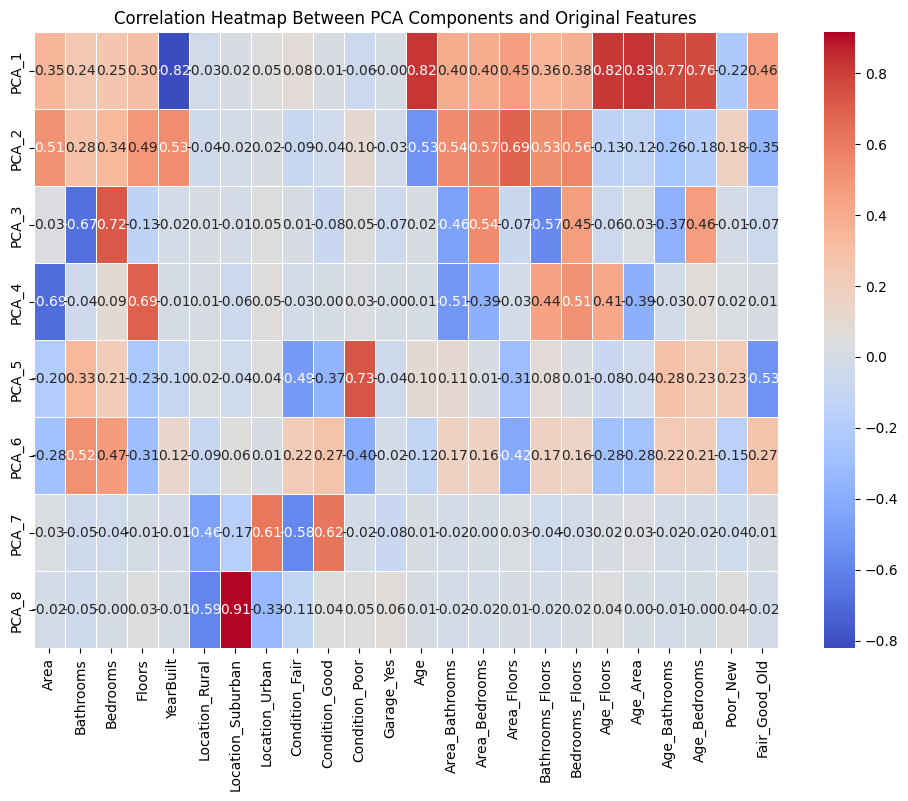

Explained Variance by PCA Components: [0.21987664 0.13583751 0.10042128 0.09047785 0.07336186 0.06770019
 0.05666496 0.05494809]
Total Variance Retained: 0.80


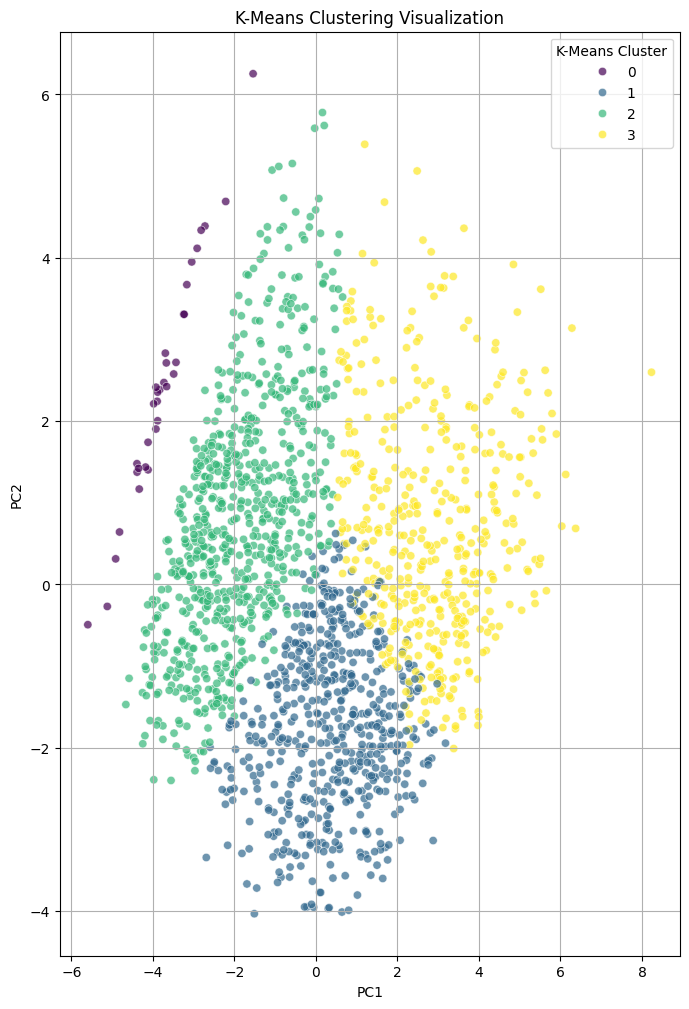

In [51]:
# Reduced dimensions for visualization

pca = PCA(n_components=8)
X_pca = pca.fit_transform(X_scaled)

# Store PCA components in Dataframe
pca_columns = [f"PCA_{i+1}" for i in range(8)]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

# Compute correlation heatmap between PCA components and original features
df_pca_with_original = pd.concat([df_pca, pd.DataFrame(X_scaled, columns=X.columns)], axis=1)
corr_matrix = df_pca_with_original.corr().loc[pca_columns, X.columns]
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True,cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap Between PCA Components and Original Features")
plt.show()





# check info retained
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance by PCA Components: {explained_variance}")
print(f"Total Variance Retained: {explained_variance.sum():.2f}")

# Scatter plot of K-Means clusters
plt.figure(figsize=(8,12))
sns.scatterplot(x=df["PCA1"], y=df["PCA2"], hue=df["Cluster"], palette="viridis", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering Visualization")
plt.legend(title="K-Means Cluster")
plt.grid(True)
plt.show()







